
# Employee Data Analysis Project

## Objective
This project performs Exploratory Data Analysis (EDA) and Machine Learning on the Employee dataset.  
The notebook includes:
- Data loading and preprocessing
- Handling duplicates and missing values
- Visualizations and charts
- Exploratory Data Analysis (EDA)
- Model building and evaluation
- Observations and insights

## Libraries Used
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn


# Importing Required Libraries
These libraries are used for data analysis, visualization, and machine learning.

In [1]:
# Importing Pandas for data manipulation
import pandas as pd
# Importing Matplotlib for plotting charts
import matplotlib.pyplot as plt
# Importing Seaborn for advanced visualizations
import seaborn as sns
# Importing NumPy for numerical operations
import numpy as np

# Loading the Dataset
Reading the employee dataset using Pandas.

In [2]:
# Reading the CSV dataset file

df = pd.read_csv("Employee.csv")

# Dataset Preview
Displaying the first few rows of the dataset.

In [3]:
# Displaying first 5 rows of the dataset

df.head()

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0
1,Bachelors,2013,Pune,1,28,Female,No,3,1
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0
3,Masters,2016,Bangalore,3,27,Male,No,5,1
4,Masters,2017,Pune,3,24,Male,Yes,2,1


# Statistical Summary
Checking statistical information of numerical columns.

In [4]:
# Generating statistical summary of dataset

df.describe()

,JoiningYear,PaymentTier,Age,ExperienceInCurrentDomain,LeaveOrNot
count,4653.000000,4653.000000,4653.000000,4653.000000,4653.000000
mean,2015.062970,2.698259,29.393295,2.905652,0.343864
std,1.863377,0.561435,4.826087,1.558240,0.475047
min,2012.000000,1.000000,22.000000,0.000000,0.000000
25%,2013.000000,3.000000,26.000000,2.000000,0.000000
50%,2015.000000,3.000000,28.000000,3.000000,0.000000
75%,2017.000000,3.000000,32.000000,4.000000,1.000000
max,2018.000000,3.000000,41.000000,7.000000,1.000000


# Dataset Information
Understanding column types and non-null values.

In [5]:
# Viewing dataset structure and data types

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4653 entries, 0 to 4652
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Education                  4653 non-null   object
 1   JoiningYear                4653 non-null   int64 
 2   City                       4653 non-null   object
 3   PaymentTier                4653 non-null   int64 
 4   Age                        4653 non-null   int64 
 5   Gender                     4653 non-null   object
 6   EverBenched                4653 non-null   object
 7   ExperienceInCurrentDomain  4653 non-null   int64 
 8   LeaveOrNot                 4653 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 327.3+ KB


# Missing Value Analysis
Checking for null values in each column.

In [6]:
# Checking total missing values in each column

df.isna().sum()

Education                    0
JoiningYear                  0
City                         0
PaymentTier                  0
Age                          0
Gender                       0
EverBenched                  0
ExperienceInCurrentDomain    0
LeaveOrNot                   0
dtype: int64

# Duplicate Value Check
Finding duplicate rows in the dataset.

In [7]:
print(df.duplicated().sum())

1889


# Removing Duplicate Rows
Cleaning the dataset by dropping duplicates.

In [8]:
# Removing duplicate rows from dataset

df.drop_duplicates(inplace=True)

# Average Age by Education
Analyzing the average employee age across education levels.

In [9]:
df.groupby("Education")["Age"].mean()

Education
Bachelors    31.306443
Masters      30.149137
PHD          29.769231
Name: Age, dtype: float64

In [10]:
df.sort_values(by="JoiningYear", ascending=True, inplace=True)

# Histogram Analysis
Visualizing the distribution of employee ages.

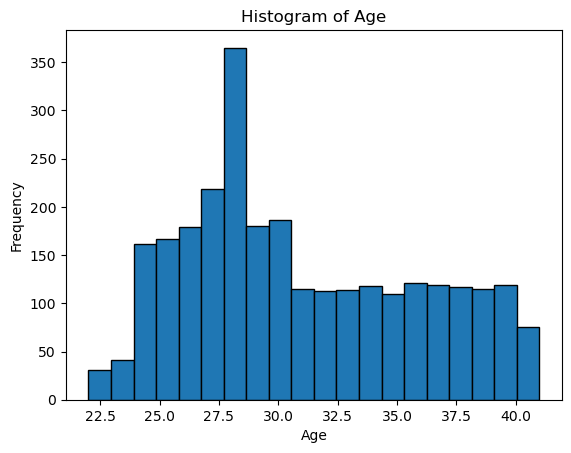

In [11]:
plt.hist(df["Age"], bins = 20, edgecolor= "black")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Histogram of Age")
plt.show()


# Gender Distribution
Analyzing the number of employees based on gender.

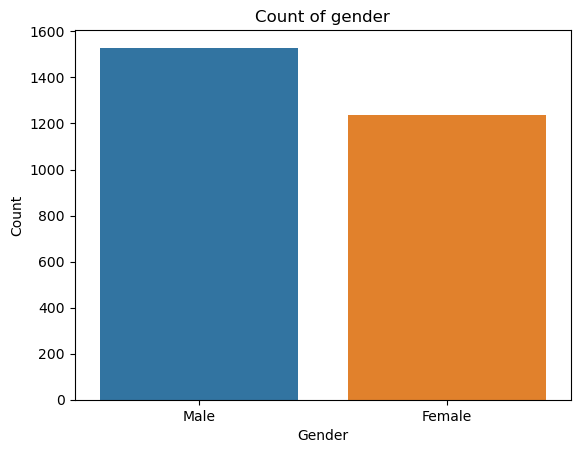

In [12]:
sns.countplot(data=df, x="Gender", hue="Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.title("Count of gender")
plt.show()

# Boxplot Analysis
Checking the spread and outliers in employee experience.

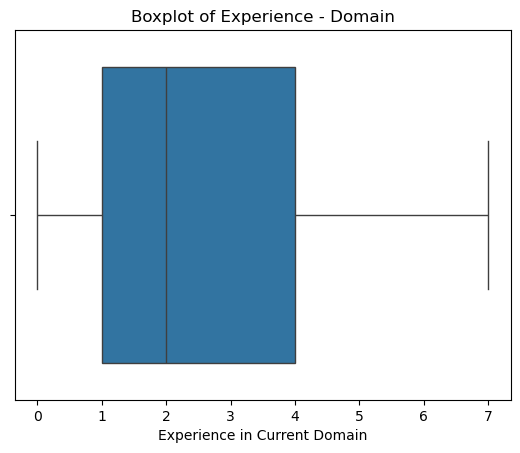

In [13]:
sns.boxplot(data=df, x = "ExperienceInCurrentDomain")
plt.xlabel("Experience in Current Domain")
plt.title("Boxplot of Experience - Domain")
plt.show()

# Scatter Plot Analysis
Understanding the relationship between age and experience.

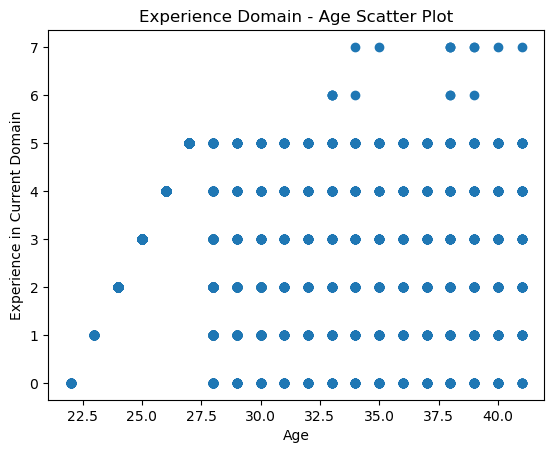

In [14]:
plt.scatter(df["Age"], df["ExperienceInCurrentDomain"])
plt.xlabel("Age")
plt.ylabel("Experience in Current Domain")
plt.title("Experience Domain - Age Scatter Plot")
plt.show()
    

# Leave Status Analysis
Checking employee leave distribution based on payment tier.

# Leave Or Not 
* 0 - Did Not Left
* 1 - Left

In [15]:
df.groupby("PaymentTier")["LeaveOrNot"].value_counts()

PaymentTier  LeaveOrNot
1            0              141
             1               77
2            1              343
             0              227
3            0             1308
             1              668
Name: count, dtype: int64

In [16]:
print(round(df[df["LeaveOrNot"]== 1]["Age"].mean(),2))

30.22


In [17]:
df.groupby("City")["City"].count()

City
Bangalore    1171
New Delhi     792
Pune          801
Name: City, dtype: int64

In [18]:
benched_percentage = df.groupby("EverBenched")["EverBenched"].count()/len(df)*100
benched_percentage

EverBenched
No     86.939219
Yes    13.060781
Name: EverBenched, dtype: float64

In [19]:
df.groupby(["Education","Gender"])["Age"].mean()

Education  Gender
Bachelors  Female    30.929530
           Male      31.619313
Masters    Female    30.348921
           Male      29.994429
PHD        Female    29.730159
           Male      29.795699
Name: Age, dtype: float64

In [20]:
df.groupby("PaymentTier")["ExperienceInCurrentDomain"].std()

PaymentTier
1    1.657295
2    1.543400
3    1.624992
Name: ExperienceInCurrentDomain, dtype: float64

In [21]:
df.groupby(["JoiningYear","Gender"])["Gender"].count()

JoiningYear  Gender
2012         Female    127
             Male      181
2013         Female    175
             Male      221
2014         Female    163
             Male      222
2015         Female    265
             Male      199
2016         Female    123
             Male      187
2017         Female    284
             Male      378
2018         Female     98
             Male      141
Name: Gender, dtype: int64

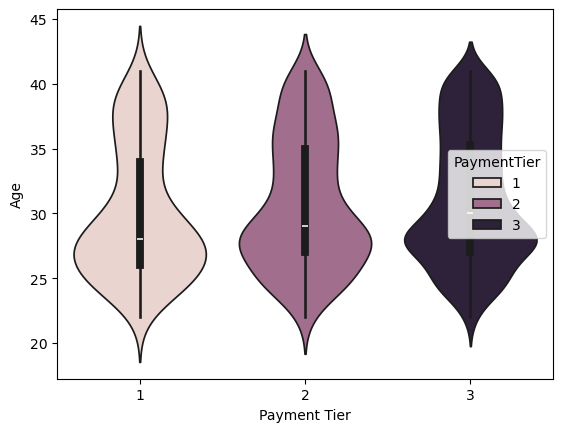

In [22]:
sns.violinplot(data=df, x= "PaymentTier", y= "Age", hue="PaymentTier")
plt.xlabel("Payment Tier")
plt.ylabel("Age")
plt.show()

* This plot show the distribution of Age within each Payment Tier

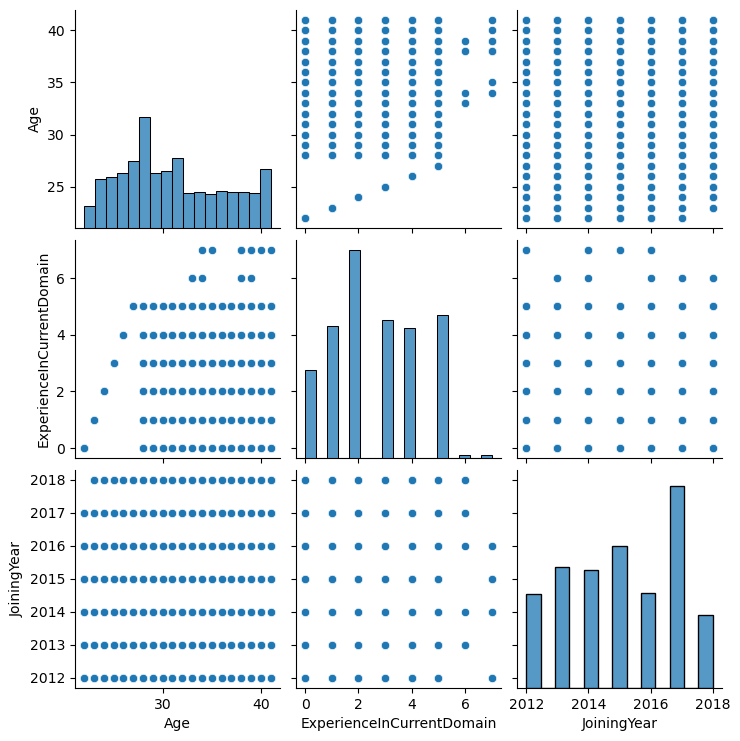

In [23]:
sns.pairplot(df[["Age","ExperienceInCurrentDomain","JoiningYear"]])
plt.show()

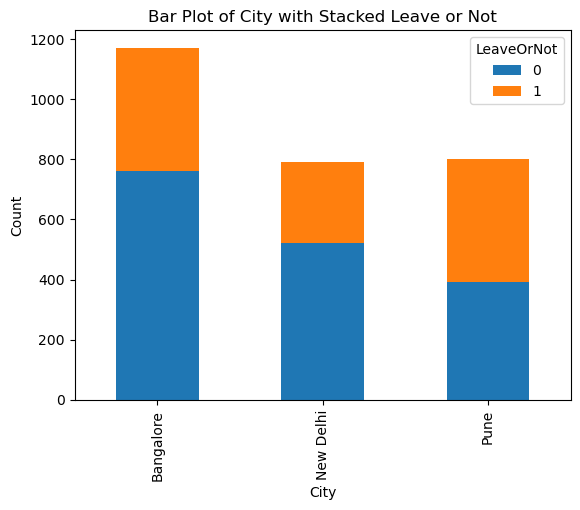

In [24]:
city_leave_counts = df.groupby("City")["LeaveOrNot"].value_counts().unstack()
city_leave_counts.plot(kind = "bar", stacked=True)
plt.xlabel("City")
plt.ylabel("Count")
plt.title("Bar Plot of City with Stacked Leave or Not")
plt.legend(title="LeaveOrNot")
plt.show()


Text(0.5, 1.0, 'Box Plot of Experience Domain - Gender')

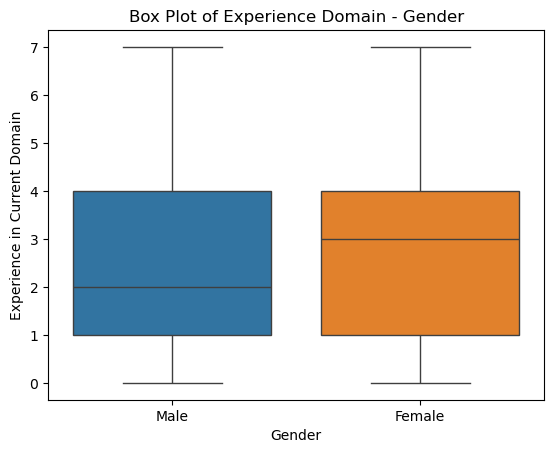

In [25]:
sns.boxplot(data = df, x="Gender", y="ExperienceInCurrentDomain", hue="Gender")
plt.xlabel("Gender")
plt.ylabel("Experience in Current Domain")
plt.title("Box Plot of Experience Domain - Gender")

* This plot show the Distribution of Experience in the current domain for each Gender

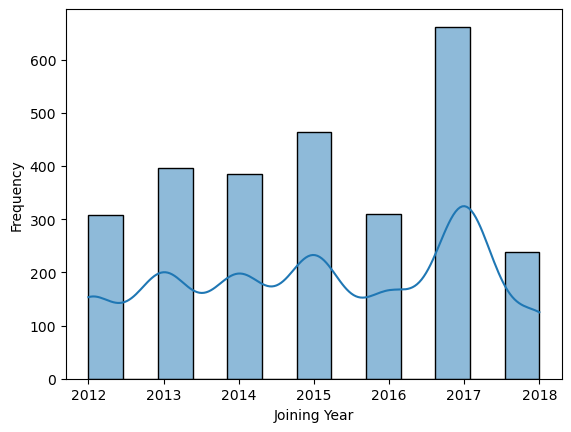

In [26]:
sns.histplot(df["JoiningYear"], kde=True)
plt.xlabel("Joining Year")
plt.ylabel("Frequency")
plt.show()

* This plot combines a Histogram with a Kernel Density Estimation for Joining Year

In [27]:
grouped = df.groupby(["Education","Gender"])["ExperienceInCurrentDomain"].mean().unstack()

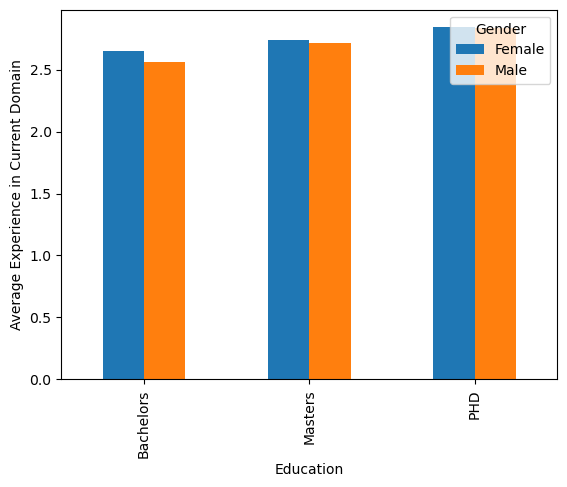

In [28]:
grouped.plot(kind="bar")
plt.xlabel("Education")
plt.ylabel("Average Experience in Current Domain")
plt.show()

* This Plot shows the Average Experience in the Current Domain for different Education Level grouped by Gender

In [29]:
grouped = df.groupby(["JoiningYear","EverBenched"])["EverBenched"].count().unstack()

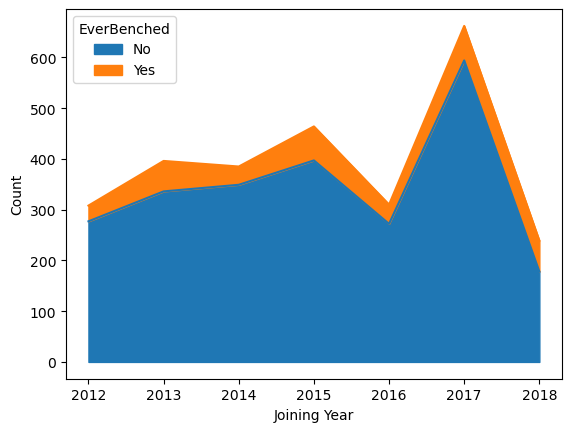

In [30]:
grouped.plot(kind="area", stacked=True)
plt.xlabel("Joining Year")
plt.ylabel("Count")
plt.legend(title="EverBenched")
plt.show()

* We are Visualizing how the Count of Employees who have been Benched change over time

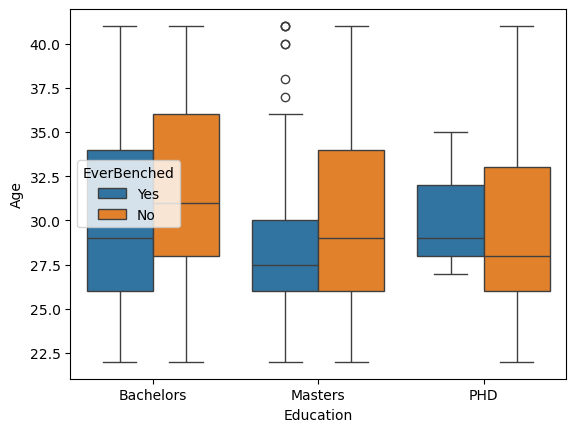

In [31]:
sns.boxplot(data= df, x="Education", y="Age", hue="EverBenched")
plt.xlabel("Education")
plt.ylabel("Age")
plt.legend(title="EverBenched")
plt.show()

* This Visualize How Age Distribution varies within different Education level and whether employees have been Benched

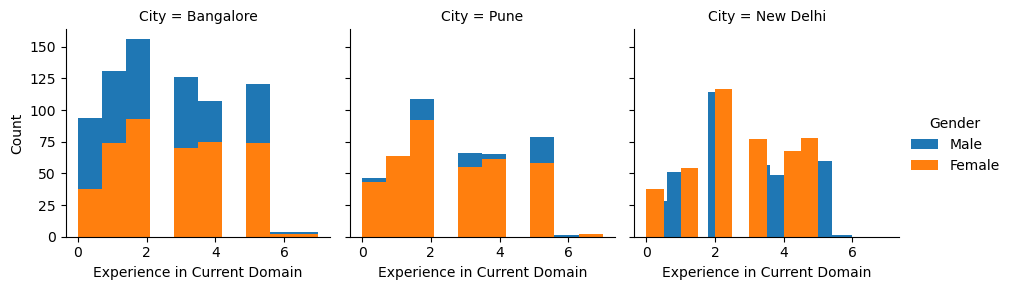

In [32]:
g = sns.FacetGrid(df, col="City", hue="Gender")
g.map(plt.hist, "ExperienceInCurrentDomain")
g.set_axis_labels("Experience in Current Domain", "Count")
g.add_legend(title= "Gender")
plt.show()

* This shows the distribution of Experience in the Current Domain for different cities grouped by Gender

In [33]:
grouped = df.groupby(["JoiningYear", "City"])["Age"].mean().unstack()

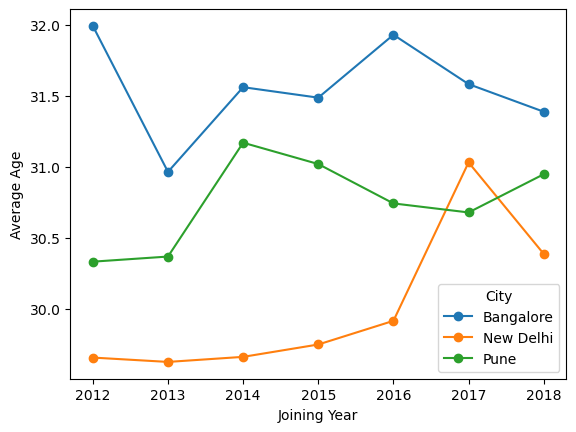

In [34]:
grouped.plot(kind = "line", marker= "o")
plt.xlabel("Joining Year")
plt.ylabel("Average Age")
plt.show()

* This shows the Average Age of Employees over years grouped by Years

## Feature Engineering

## What is Feature Engineering?
Feature Engineering is the process of transforming raw data into meaningful input features that improve machine learning model performance.

## Steps Performed
- Selecting important input and target variables
- Encoding categorical variables into numerical format
- Scaling and normalizing data when required
- Splitting the dataset into training and testing sets

## Importance
Feature engineering helps:
- Improve model accuracy
- Reduce model complexity
- Handle categorical data effectively
- Prepare data for machine learning algorithms

## Observation
- Proper feature engineering improves prediction quality.
- Encoded and cleaned data helps machine learning models learn patterns more efficiently.


In [35]:
df.columns

Index(['Education', 'JoiningYear', 'City', 'PaymentTier', 'Age', 'Gender',
       'EverBenched', 'ExperienceInCurrentDomain', 'LeaveOrNot'],
      dtype='object')

In [36]:
X = df.iloc[:, : -1]

In [37]:
X

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain
4651,Bachelors,2012,Bangalore,3,30,Male,Yes,2
3052,Bachelors,2012,Bangalore,3,34,Male,No,1
3054,Bachelors,2012,Bangalore,3,39,Female,No,2
3055,Bachelors,2012,Bangalore,3,41,Male,No,3
3058,Bachelors,2012,Bangalore,3,33,Male,No,2
...,...,...,...,...,...,...,...,...
2221,Bachelors,2018,Pune,3,29,Male,Yes,1
2529,Masters,2018,New Delhi,3,30,Female,No,4
70,Bachelors,2018,Bangalore,3,23,Female,No,1
3267,Bachelors,2018,New Delhi,3,35,Female,No,2


In [38]:
y= df.iloc[:, -1]


In [39]:
y

4651    0
3052    0
3054    0
3055    0
3058    0
       ..
2221    1
2529    1
70      1
3267    1
3293    1
Name: LeaveOrNot, Length: 2764, dtype: int64

In [40]:
X.drop(columns=["JoiningYear", "City", "Age"], inplace=True)

In [41]:
X

,Education,PaymentTier,Gender,EverBenched,ExperienceInCurrentDomain
4651,Bachelors,3,Male,Yes,2
3052,Bachelors,3,Male,No,1
3054,Bachelors,3,Female,No,2
3055,Bachelors,3,Male,No,3
3058,Bachelors,3,Male,No,2
...,...,...,...,...,...
2221,Bachelors,3,Male,Yes,1
2529,Masters,3,Female,No,4
70,Bachelors,3,Female,No,1
3267,Bachelors,3,Female,No,2


In [42]:
from sklearn import preprocessing
labelencoder = preprocessing.LabelEncoder() # Creating Label Encoder for categorical encoding

In [43]:

X["Education"] = labelencoder.fit_transform(X["Gender"])

In [44]:
X["Gender"] = labelencoder.fit_transform(X["Gender"])
X["EverBenched"] = labelencoder.fit_transform(X["EverBenched"])

In [45]:
X

,Education,PaymentTier,Gender,EverBenched,ExperienceInCurrentDomain
4651,1,3,1,1,2
3052,1,3,1,0,1
3054,0,3,0,0,2
3055,1,3,1,0,3
3058,1,3,1,0,2
...,...,...,...,...,...
2221,1,3,1,1,1
2529,0,3,0,0,4
70,0,3,0,0,1
3267,0,3,0,0,2


In [46]:
from sklearn.model_selection import train_test_split  # Splitting dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2) 

In [47]:
from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler()  # Creating StandardScaler object for feature scaling
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.fit_transform(X_test)

In [48]:
from sklearn.metrics import accuracy_score
def modelperformance(predictions):
    print("Accuracy score in model is {}".format(accuracy_score(y_test, predictions))) # Calculating model accuracy

In [49]:
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression()
log_model.fit(scaled_X_train, y_train)  # Training the machine learning model

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [50]:
log_predictions = log_model.predict(scaled_X_test)  # Predicting output using trained model
modelperformance(log_predictions)

Accuracy score in model is 0.6726943942133815


In [51]:
from sklearn.model_selection import GridSearchCV

In [52]:
from sklearn.neighbors import KNeighborsClassifier

In [53]:
param_grid = {"n_neighbors" : [3, 5, 7, 9, 11],
             "weights" : ["uniform", "distance"],
             "algorithm" : ["auto","ball_tree","kd_tree","brute"]}
gridkn = GridSearchCV(KNeighborsClassifier(), param_grid, cv= 3)
gridkn.fit(scaled_X_train, y_train)

,estimator,KNeighborsClassifier()
,param_grid,"{'algorithm': ['auto', 'ball_tree', ...], 'n_neighbors': [3, 5, ...], 'weights': ['uniform', 'distance']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,11


In [54]:
print("Best parameters", gridkn.best_params_)

Best parameters {'algorithm': 'ball_tree', 'n_neighbors': 11, 'weights': 'uniform'}


In [55]:
knpreds = gridkn.predict(scaled_X_test)
modelperformance(knpreds)

Accuracy score in model is 0.6220614828209765


In [56]:
from sklearn.svm import SVC
svm = SVC()
param_grid = {"C" : [0.01, 0.1, 0.5, 1], "kernel" : ["linear", "rbf", "poly"]}

In [57]:
gridsvc = GridSearchCV(svm, param_grid, cv= 3)
gridsvc.fit(scaled_X_train, y_train)

,estimator,SVC()
,param_grid,"{'C': [0.01, 0.1, ...], 'kernel': ['linear', 'rbf', ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,0.1


In [58]:
gridsvc.best_params_

{'C': 0.1, 'kernel': 'poly'}

In [59]:
pred_svc = gridsvc.predict(scaled_X_test)
modelperformance(pred_svc)

Accuracy score in model is 0.6726943942133815


In [60]:
from sklearn.tree import DecisionTreeClassifier
param_grid = {
    "criterion" : ["gini", "entropy"],
    "splitter" : ["best", "random"],
    "max_depth" : [None, 10, 20, 30, 40, 50],
    "min_samples_split" : [2, 5, 10],
    "min_samples_leaf" : [1, 2, 4]
}
grid_search_tree = GridSearchCV(DecisionTreeClassifier(), param_grid, cv= 3)
grid_search_tree.fit(scaled_X_train, y_train) 

,estimator,DecisionTreeClassifier()
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,scoring,None
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'entropy'


In [61]:
grid_search_tree.best_params_

{'criterion': 'entropy',
 'max_depth': 10,
 'min_samples_leaf': 4,
 'min_samples_split': 10,
 'splitter': 'random'}

In [62]:
preds = grid_search_tree.predict(scaled_X_test)
modelperformance(preds)

Accuracy score in model is 0.674502712477396


In [63]:
from sklearn.ensemble import RandomForestClassifier
rfc_model = RandomForestClassifier()
n_estimators = [32, 64, 128, 256]
max_features = [2,3,4]
bootstrap = [True, False]
oob_score = [True, False]
param_grid = {"n_estimators" : n_estimators, "max_features": max_features, "bootstrap" : bootstrap, "oob_score" : oob_score}  
grid_rfc = GridSearchCV(rfc_model, param_grid, cv= 3)
grid_rfc.fit(scaled_X_train, y_train)

C:\Users\vardh\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
36 fits failed out of a total of 144.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
36 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\vardh\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\vardh\anaconda3\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "C:\Users\vardh\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py", line 447, in fit
    raise ValueError

,estimator,RandomForestClassifier()
,param_grid,"{'bootstrap': [True, False], 'max_features': [2, 3, ...], 'n_estimators': [32, 64, ...], 'oob_score': [True, False]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,64


In [64]:
grid_rfc.best_params_

{'bootstrap': True, 'max_features': 4, 'n_estimators': 64, 'oob_score': False}

In [65]:
preds = grid_rfc.predict(scaled_X_test)
modelperformance(preds)

Accuracy score in model is 0.6672694394213382



# Final Observations and Conclusion

## Key Insights
- Employee age distribution appears mostly concentrated within a specific range.
- Gender distribution helps identify workforce balance.
- Experience and age show noticeable trends through scatter analysis.
- Payment tier and employee leave status may indicate employee retention patterns.

## Model Observation
- Different machine learning models can be compared using accuracy and evaluation metrics.
- Visualization helps identify important employee behavior trends.
- Data preprocessing improves overall model performance.

## Conclusion
This project demonstrates how EDA and visualization techniques help understand employee datasets and improve predictive analysis workflows.
